In [9]:
import fiftyone as fo
import fiftyone.zoo as foz
import os

In [2]:
fo.config.dataset_zoo_dir = "G:/datasets"
import torch

device = torch.device("cpu")

In [7]:
train = fiftyone.zoo.load_zoo_dataset(
              "open-images-v7",
              split= "validation",
              label_types=["segmentations"],
              classes=["Car", "Motorcycle", "Bus"],
              max_samples=750
          )

Only found 497 (<750) samples matching your requirements
 100% |███████████████████| 497/497 [25.3s elapsed, 0s remaining, 16.5 files/s]      
Dataset info written to 'G:/datasets\open-images-v7\info.json'
Loading 'open-images-v7' split 'validation'
 100% |█████████████████| 497/497 [16.9s elapsed, 0s remaining, 32.3 samples/s]      
Dataset 'open-images-v7-validation-750' created


In [3]:
dataset = fo.zoo.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["segmentations"],
    dataset_dir="G:/datasets/open-images-v7",
    max_samples=750,
)

Necessary images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'open-images-v7-train-750'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [4]:
dataset.compute_metadata()

In [5]:
sample = dataset.first()
print(sample.metadata.height, sample.metadata.width)

768 1024


In [12]:
output_mask_dir = "G:/datasets/open-images-v7/train/labels/masks"

In [13]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = size  # target (width, height)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        # Resize
        image = image.resize(self.size, Image.BILINEAR)
        mask = mask.resize(self.size, Image.NEAREST)

        # To numpy
        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.int64)

        # To torch
        image = torch.from_numpy(image).permute(2, 0, 1)  # CHW
        mask = torch.from_numpy(mask)

        return image, mask

In [23]:
labels_found = set()
for sample in dataset:
    for det in sample["ground_truth"].detections:
        labels_found.add(det.label)

print("Labels in dataset:", labels_found)

Labels in dataset: {'Person', 'Boot', 'Wheel', 'Flag', 'Clothing', 'Boy', 'Taxi', 'Bus', 'Toy', 'Woman', 'Balloon', 'Miniskirt', 'Skyscraper', 'Bicycle wheel', 'Vehicle registration plate', 'Hat', 'Truck', 'Car', 'Jeans', 'Cattle', 'Man', 'Cat', 'Trousers', 'Van', 'Shorts', 'Motorcycle', 'Sun hat', 'Aircraft', 'Stop sign', 'Segway', 'Traffic light', 'Horse', 'Carnivore', 'Girl', 'Train', 'Swan', 'Dress', 'Skateboard', 'Traffic sign', 'Human body', 'Parrot', 'Backpack', 'Seat belt', 'Bull', 'Dog'}


In [26]:
import numpy as np
from PIL import Image
import os

output_mask_dir = "G:/datasets/open-images-v7/train/labels/masks"
os.makedirs(output_mask_dir, exist_ok=True)

image_paths = []
mask_paths = []

# Map label name → class ID
label_map = {
    "Car": 1,
    "Motorcycle": 2,
    "Bus": 3,
}


for sample in dataset:
    detections = sample["ground_truth"].detections
    height = sample.metadata.height
    width = sample.metadata.width

    mask = np.zeros((height, width), dtype=np.uint8)

    for det in detections:
        class_id = label_map.get(det.label)
        if class_id is None:
            continue  # skip classes that we don't need

        class_id = label_map.get(det.label)
        if class_id is None:
            continue  # skip unknown classes

        binary_mask = det.mask.astype(np.uint8)

        x, y, w, h = det.bounding_box
        x1 = int(x * width)
        y1 = int(y * height)
        x2 = int((x + w) * width)
        y2 = int((y + h) * height)

        if x2 <= x1 or y2 <= y1:
            continue

        resized = Image.fromarray(binary_mask * 255).resize(
            (x2 - x1, y2 - y1), resample=Image.NEAREST
        )
        resized_mask = np.array(resized) > 0

        mask[y1:y2, x1:x2][resized_mask] = class_id

    if np.any(mask):
        mask_path = os.path.join(output_mask_dir, f"{sample.id}.png")
        Image.fromarray(mask).save(mask_path)

        image_paths.append(sample.filepath)
        mask_paths.append(mask_path)

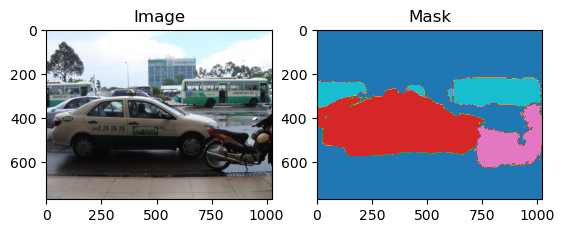

In [25]:
from matplotlib import pyplot as plt

img = np.array(Image.open(image_paths[0]))
mask = np.array(Image.open(mask_paths[0]))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab10")
plt.title("Mask")

plt.show()

In [29]:
mask_paths[0]

'G:/datasets/open-images-v7/train/labels/masks\\67eaebfc6d67fd67ecb3e90c.png'

In [26]:
fo.pprint(dataset.stats(include_media=True))

AttributeError: 'SegmentationDataset' object has no attribute 'stats'

In [30]:
dataset = SegmentationDataset(image_paths, mask_paths, size = (256, 256))

In [31]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, num_classes):
        super(UNet, self).__init__()
        
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [42]:
model = UNet(num_classes=4).to(device)

In [49]:
model

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_r